# Toronto Airbnb Review-Rate Modeling

Estimate observed monthly review frequency from listing data, including title text. This regression study uses 22,256 Toronto listings and excludes explicit review-history predictors. Review frequency is a proxy for booking activity, not a direct measure of occupancy, revenue, or future demand.

## Setup

Verification replayed archived development results and freshly refitted the final model, reproducing the reported test metrics.  The full search was not rerun from an empty cache; recorded CV/search timings come from the original experiment. Standard runs use the versioned cache below, not the archived flat files.

In [1]:
import warnings
import hashlib
import json
from importlib.metadata import version
from pathlib import Path
from typing import Any, Callable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings(
    "ignore", message=".*encountered in matmul.*", category=RuntimeWarning,
    module=r"sklearn\.linear_model\._base",
)
warnings.filterwarnings(
    "ignore", message=".*does not have valid feature names.*", category=UserWarning,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", palette="muted")

RANDOM_STATE = 42
TARGET = "reviews_per_month"
DATA_PATH = "data/AB_TRT_2026.csv"

CACHE = Path("cache")
IMG = Path("img")
CACHE.mkdir(exist_ok=True)
IMG.mkdir(exist_ok=True)

# Save the notebook and restart its kernel after changing an experiment.
# Data, saved code, and package versions define an isolated cache namespace.
NOTEBOOK_PATH = Path("toronto-airbnb-demand.ipynb")
_code_cells = [
    cell["source"] for cell in json.loads(NOTEBOOK_PATH.read_text())["cells"]
    if cell["cell_type"] == "code"
]
_versions = {
    package: version(package) for package in [
        "numpy", "pandas", "scipy", "scikit-learn", "lightgbm",
        "xgboost", "catboost", "shap", "joblib",
    ]
}
DATA_SHA256 = hashlib.sha256(Path(DATA_PATH).read_bytes()).hexdigest()
CACHE_KEY = joblib.hash((DATA_SHA256, _code_cells, _versions))[:16]
RUN_CACHE = CACHE / CACHE_KEY
RUN_CACHE.mkdir(exist_ok=True)

DROP_COLS = [
    "number_of_reviews",      # review history, unavailable before posting
    "last_review",            # review history, unavailable before posting
    "number_of_reviews_ltm",  # review history, unavailable before posting
    "neighbourhood_group",    # empty in every row
    "id",                     # database identifier
    "host_id",                # database identifier
    "host_profile_id",        # database identifier
    "host_name",              # personal identifier, not a property attribute
]


def load_raw() -> pd.DataFrame:
    """Read the listings file exactly as delivered. No cleaning here."""
    return pd.read_csv(DATA_PATH)


def cached(name: str, fn: Callable[[], Any], force: bool = False) -> Any:
    """Reuse this experiment's result; write atomically after a successful run."""
    path = RUN_CACHE / f"{name}.joblib"
    if path.exists() and not force:
        try:
            return joblib.load(path)
        except Exception as exc:
            warnings.warn(f"Recomputing unreadable cache {path.name}: {exc}")

    result = fn()
    tmp = path.with_suffix(".tmp")
    joblib.dump(result, tmp)
    tmp.replace(path)
    return result


def save_fig(fig, name: str) -> None:
    fig.savefig(IMG / f"{name}.png", dpi=150, bbox_inches="tight")


def expm1_floor(y):
    """Undo the log transform, then floor at zero.

    A negative review rate is impossible, but a model fitted in log space can
    produce one. Defined as a named function rather than written inline so that
    fitted models can be saved to disk.
    """
    values = np.expm1(y)
    if not np.isfinite(values).all():
        raise ValueError("Non-finite predictions after inverse target transform")
    return np.clip(values, 0, None)


SCORING = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
}


def summarize_cv(cv_results: dict, label: str) -> pd.DataFrame:
    """Turn a cross_validate result into one readable row, all in original units."""
    return pd.DataFrame(
        [{
            "model": label,
            "fit_time": cv_results["fit_time"].mean(),
            "score_time": cv_results["score_time"].mean(),
            "train_r2": cv_results.get("train_r2", np.array([np.nan])).mean(),
            "r2": cv_results["test_r2"].mean(),
            "r2_std": cv_results["test_r2"].std(),
            "rmse": -cv_results["test_rmse"].mean(),
            "mae": -cv_results["test_mae"].mean(),
        }]
    ).set_index("model")

Validate the dataset shape, required fields, and the relationship between missing review rates and zero recorded reviews.

In [3]:
_raw = load_raw()
assert _raw.shape == (22256, 19), f"unexpected shape {_raw.shape}"
assert TARGET in _raw.columns
assert _raw["neighbourhood_group"].isna().all(), "neighbourhood_group is no longer empty"
assert (_raw[TARGET].isna() == (_raw["number_of_reviews"] == 0)).all(), (
    "a missing review rate no longer lines up exactly with zero reviews"
)
print(f"{_raw.shape[0]:,} listings, {_raw.shape[1]} columns")

22,256 listings, 19 columns


---

## 1. Problem and data

**Task:** estimate `reviews_per_month` for held-out listings with an observed review rate, using listing data from a single snapshot.

**Business motivation:** explore whether listing information such as price, location, room type, minimum stay, and title can estimate expected review activity. Airbnb could use  this sort of model to predict how popular future listings might be **before  they are posted**, perhaps to help guide hosts create more appealing listings

The data comes from [Inside Airbnb](https://insideairbnb.com/get-the-data/), provided locally as `data/AB_TRT_2026.csv`. The exact snapshot date and original download URL were not retained. The latest review date is not a collection date.

| Inputs | Representation |
| --- | --- |
| `name` | Listing title |
| `neighbourhood`, `room_type`, `license` | Categories |
| `latitude`, `longitude` | Location |
| `price`, `minimum_nights` | Listed price and minimum stay |
| `calculated_host_listings_count`, `availability_365` | Host portfolio size and calendar availability |

Exclude `number_of_reviews`, `last_review`, and `number_of_reviews_ltm` to avoid direct review-history predictors. Also remove the empty `neighbourhood_group`, identifiers (`id`, `host_id`, `host_profile_id`), and `host_name`, which is not a property attribute and may encode personal information.

In [4]:
df = load_raw()
print(f"{df.shape[0]:,} listings, {df.shape[1]} columns\n")

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(1),
    "n_unique": df.nunique(),
})
overview

22,256 listings, 19 columns



,dtype,missing,missing_pct,n_unique
id,int64,0,0.0,22256
name,object,0,0.0,21839
host_id,float64,44,0.2,14808
host_profile_id,float64,45,0.2,14807
host_name,object,45,0.2,7411
neighbourhood_group,float64,22256,100.0,0
neighbourhood,object,0,0.0,140
latitude,float64,0,0.0,12458
longitude,float64,0,0.0,14744
room_type,object,0,0.0,4


In [5]:
print(f"Columns in the file:                {df.shape[1]}")
print(f"Dropped as unusable or unsafe:      {len(DROP_COLS)}")
print(f"Left to predict from, plus target:  {df.shape[1] - len(DROP_COLS)}")

Columns in the file:                19
Dropped as unusable or unsafe:      8
Left to predict from, plus target:  11


The file contains 22,256 listings and 19 columns: 10 candidate inputs, one target, and eight excluded columns. Price is missing in 21.0% of rows, the target in 21.8%, and the license field in 45.9%. All 4,855 missing targets correspond to zero recorded reviews. The 12,030 non-missing license entries include codes and exemptions.

---

## 2. Data splitting and missing targets

Split listings 80/20 with seed 42 before target-based exploration or model fitting. Use five-fold cross-validation within the training partition for model selection. Reserve the test partition for final evaluation; model choices use development results.

Evaluate predictions on the original target scale using R², RMSE, and MAE. R² measures improvement over the evaluation-set mean, while RMSE gives more weight to large errors and MAE reports average absolute error. RMSE and MAE are measured in reviews per month.

In [6]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

print(f"train: {len(train_df):,} listings")
print(f"test:  {len(test_df):,} listings")
print(f"missing target in train: {train_df[TARGET].isna().sum():,} "
      f"({train_df[TARGET].isna().mean():.1%})")

train: 17,804 listings
test:  4,452 listings
missing target in train: 3,848 (21.6%)


### Missing-target policy

Compare two training policies:

- **Drop:** train only on listings with an observed review rate.
- **Fill zero:** include all training listings and assign zero to missing rates.

For each fold, fit both policies and score them on the same validation rows with observed targets. This holds the evaluation population and R² denominator fixed. The comparison selects a policy for observed-rate prediction.

In [7]:
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error


def compare_target_policies(frame, model_factory, n_splits=5):
    """Score dropping the missing-target rows against filling them with zero.

    Both variants train differently but are scored on identical rows: the
    validation listings with a genuinely observed target. Without that, the two
    numbers would not be comparable.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    X_all = frame.drop(columns=[TARGET])
    y_all = frame[TARGET]
    rows = []

    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_all)):
        X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        y_tr, y_va = y_all.iloc[tr_idx], y_all.iloc[va_idx]

        seen = y_va.notna().to_numpy()          # the shared scoring rows
        X_eval, y_eval = X_va[seen], y_va[seen]

        observed = y_tr.notna().to_numpy()
        drop_model = model_factory().fit(X_tr[observed], y_tr[observed])
        fill_model = model_factory().fit(X_tr, y_tr.fillna(0))

        for policy, model in [("drop", drop_model), ("fill0", fill_model)]:
            pred = model.predict(X_eval)
            rows.append({
                "fold": fold,
                "policy": policy,
                "r2": r2_score(y_eval, pred),
                "rmse": root_mean_squared_error(y_eval, pred),
                "mae": mean_absolute_error(y_eval, pred),
            })

    return pd.DataFrame(rows)

The initial comparison uses Ridge with six numeric features: price, minimum stay, latitude, longitude, host listing count, and availability. Missing inputs are median-imputed and standardized; the target uses `log1p`.

In [8]:
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler

PROVISIONAL_NUMERIC = [
    "price", "minimum_nights", "latitude", "longitude",
    "calculated_host_listings_count", "availability_365",
]


def provisional_model():
    prep = ColumnTransformer(
        [("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()),
          PROVISIONAL_NUMERIC)],
        remainder="drop",
    )
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", prep), ("model", Ridge())]),
        func=np.log1p,
        inverse_func=expm1_floor,
    )


policy_scores = cached(
    "policy_comparison_provisional",
    lambda: compare_target_policies(train_df, provisional_model),
)
policy_scores.groupby("policy")[["r2", "rmse", "mae"]].agg(["mean", "std"]).round(4)

r2            rmse             mae        
          mean     std    mean     std    mean     std
policy                                                
drop    0.0731  0.0221  1.6608  0.0141  1.0557  0.0253
fill0  -0.0185  0.0088  1.7412  0.0294  1.0576  0.0253

In [9]:
means = policy_scores.groupby("policy")["r2"].mean()
stds = policy_scores.groupby("policy")["r2"].std()

TARGET_POLICY = means.idxmax()

print(means.round(4).to_string())
print(f"\ngap between the two:            {abs(means['drop'] - means['fill0']):.4f}")
print(f"fold to fold variation, drop:   {stds['drop']:.4f}")
print(f"fold to fold variation, fill0:  {stds['fill0']:.4f}")
print(f"\nchosen policy: {TARGET_POLICY}")

policy
drop     0.0731
fill0   -0.0185

gap between the two:            0.0915
fold to fold variation, drop:   0.0221
fold to fold variation, fill0:  0.0088

chosen policy: drop


Dropping missing targets gives mean validation R² 0.0731, compared with −0.0185 for zero filling. We retain the drop policy for the observed-rate task.

Removing missing targets excludes 3,848 training listings. All later results therefore apply only to listings with recorded  review rates. This experiment does not determine how best to model listings with no reviews. Variation across the five CV folds indicates sensitivity to the data split, not whether differences between models are statistically significant.

In [10]:
def apply_policy(frame: pd.DataFrame, policy: str) -> pd.DataFrame:
    out = frame.copy()
    if policy == "drop":
        return out[out[TARGET].notna()]
    if policy != "fill0":
        raise ValueError(f"Unknown target policy: {policy}")
    out[TARGET] = out[TARGET].fillna(0)
    return out


train_use = apply_policy(train_df, TARGET_POLICY)
test_use = apply_policy(test_df, TARGET_POLICY)


def to_xy(frame: pd.DataFrame):
    """Split off the target and remove every column the model may not see."""
    X = frame.drop(columns=[TARGET] + DROP_COLS)
    return X, frame[TARGET]


X_train, y_train = to_xy(train_use)
X_test, y_test = to_xy(test_use)

assert y_train.isna().sum() == 0
assert not set(DROP_COLS) & set(X_train.columns), "a dropped column survived"
assert "number_of_reviews" not in X_train.columns

print(f"training on {len(X_train):,} listings, {X_train.shape[1]} usable columns")
print(f"held back for the final test: {len(X_test):,} listings")
print(f"\ncolumns the model may see:\n  {sorted(X_train.columns)}")

training on 13,956 listings, 10 usable columns
held back for the final test: 3,445 listings

columns the model may see:
  ['availability_365', 'calculated_host_listings_count', 'latitude', 'license', 'longitude', 'minimum_nights', 'name', 'neighbourhood', 'price', 'room_type']


The resulting data contains 13,956 training listings and 3,445 test listings with observed targets. Assertions check that review-history predictors are excluded. The random split may place different listings from the same host in both partitions; it does not measure generalization to entirely new hosts.

---

## 3. Exploratory data analysis

All target-related exploration below uses the observed-target training partition.

In [11]:
train_eda = X_train.copy()
train_eda[TARGET] = y_train

print(train_eda[TARGET].describe().round(3).to_string())
print(f"\nskew, raw:    {train_eda[TARGET].skew():.3f}")
print(f"skew, log1p:  {np.log1p(train_eda[TARGET]).skew():.3f}")

count    13956.000
mean         1.416
std          1.726
min          0.010
25%          0.200
50%          0.730
75%          2.090
max         34.510

skew, raw:    2.443
skew, log1p:  0.702


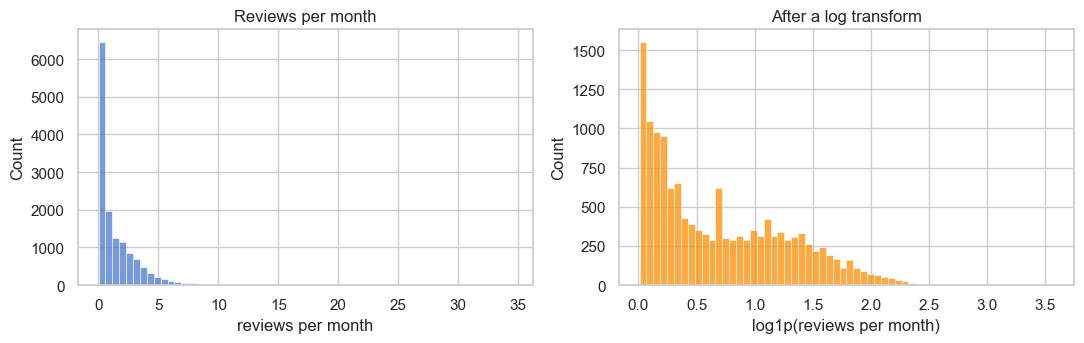

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
sns.histplot(train_eda[TARGET], bins=60, ax=axes[0])
axes[0].set_title("Reviews per month")
axes[0].set_xlabel("reviews per month")
sns.histplot(np.log1p(train_eda[TARGET]), bins=60, ax=axes[1], color="darkorange")
axes[1].set_title("After a log transform")
axes[1].set_xlabel("log1p(reviews per month)")
fig.tight_layout()
save_fig(fig, "target_distribution")
plt.show()

The target is right-skewed: skewness falls from 2.443 to 0.702 after `log1p`. Substantive models use this transformed target to reduce the influence of large absolute errors during fitting. Predictions are converted back for evaluation.

This changes the training objective; it does not guarantee lower original-scale error. A raw-target model ablation would be needed to measure the transform's benefit.

### Minimum-stay segments

Toronto defines short-term rentals as stays of fewer than 28 consecutive days; registration requirements include exemptions, such as hotels ([City of Toronto](https://www.toronto.ca/community-people/housing-shelter/rental-housing-rights-information/short-term-rentals/)). We use the 28-night minimum-stay boundary to define two descriptive segments. A listing's minimum stay does not identify its actual booking durations or compliance.

In [13]:
top_nights = train_eda["minimum_nights"].value_counts().head(10)
print("most common minimum stays")
print(top_nights.to_string())
print(f"\nexactly 28 nights: {(train_eda['minimum_nights'] == 28).mean():.1%} of listings")
print(f"28 or more:        {(train_eda['minimum_nights'] >= 28).mean():.1%} of listings")

most common minimum stays
minimum_nights
28    6173
1     3881
2     1773
30     602
3      474
29     234
31     211
5       89
4       84
90      60

exactly 28 nights: 44.2% of listings
28 or more:        54.4% of listings


In [14]:
train_eda["market"] = np.where(
    train_eda["minimum_nights"] >= 28,
    "B: 28 nights and up",
    "A: under 28 nights",
)

by_market = train_eda.groupby("market").agg(
    listings=("market", "size"),
    median_price=("price", "median"),
    median_availability=("availability_365", "median"),
    median_target=(TARGET, "median"),
    mean_target=(TARGET, "mean"),
    pct_entire_home=("room_type", lambda s: (s == "Entire home/apt").mean() * 100),
    pct_license_present=("license", lambda s: s.notna().mean() * 100),
).round(2)
by_market.T

market,A: under 28 nights,B: 28 nights and up
listings,6367.00,7589.00
median_price,305.00,108.00
median_availability,194.00,175.00
median_target,2.12,0.24
mean_target,2.53,0.48
pct_entire_home,71.12,68.31
pct_license_present,97.94,32.94


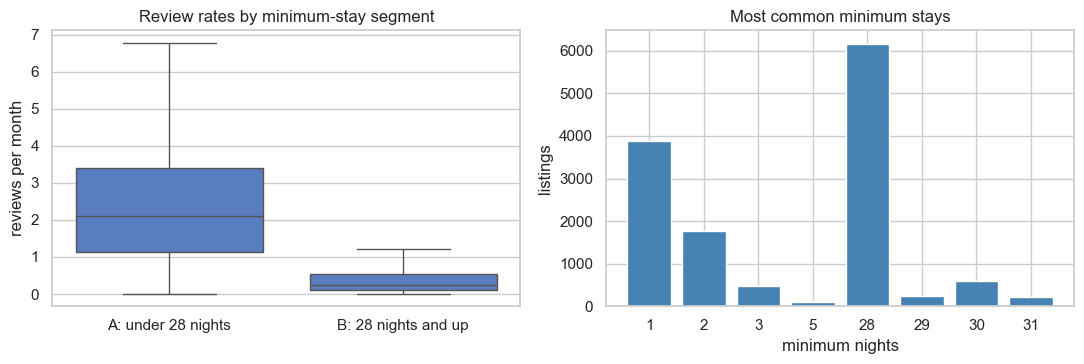

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

sns.boxplot(data=train_eda, x="market", y=TARGET, ax=axes[0], showfliers=False)
axes[0].set_title("Review rates by minimum-stay segment")
axes[0].set_xlabel("")
axes[0].set_ylabel("reviews per month")

counts = train_eda["minimum_nights"].value_counts().head(8).sort_index()
axes[1].bar(counts.index.astype(str), counts.values, color="steelblue")
axes[1].set_title("Most common minimum stays")
axes[1].set_xlabel("minimum nights")
axes[1].set_ylabel("listings")

fig.tight_layout()
save_fig(fig, "two_markets")
plt.show()

In [16]:
train_eda["license_status"] = np.where(
    train_eda["license"].isna(), "missing",
    np.where(train_eda["license"] == "Exempt", "exempt", "has_code"),
)

print("share of each license status falling in each market")
print(pd.crosstab(train_eda["license_status"], train_eda["market"],
                  normalize="index").round(3).to_string())

print("\nreview rate by license status")
print(train_eda.groupby("license_status")[TARGET]
      .agg(["count", "median", "mean"]).round(3).to_string())

share of each license status falling in each market
market          A: under 28 nights  B: 28 nights and up
license_status                                         
exempt                       0.227                0.773
has_code                     0.718                0.282
missing                      0.025                0.975

review rate by license status
                count  median   mean
license_status                      
exempt             66    0.39  0.638
has_code         8670    1.64  2.062
missing          5220    0.19  0.353


In [17]:
print("review rate by room type")
print(train_eda.groupby("room_type")[TARGET]
      .agg(["count", "median", "mean"]).round(3).to_string())

print("\nreview rate by market and room type")
print(train_eda.groupby(["market", "room_type"])[TARGET]
      .agg(["count", "median"]).round(3).to_string())

review rate by room type
                 count  median   mean
room_type                            
Entire home/apt   9712   0.810  1.431
Hotel room          42   3.875  3.799
Private room      4191   0.540  1.359
Shared room         11   0.720  1.055

review rate by market and room type
                                     count  median
market              room_type                     
A: under 28 nights  Entire home/apt   4528    2.14
                    Hotel room          41    3.91
                    Private room      1793    2.05
                    Shared room          5    1.68
B: 28 nights and up Entire home/apt   5184    0.26
                    Hotel room           1    0.01
                    Private room      2398    0.20
                    Shared room          6    0.13


### Observed differences

44.2% of observed-target training listings specify exactly 28 nights, and 54.4% specify at least 28. This concentration is consistent with the regulatory boundary, but the snapshot cannot establish why individual hosts chose it.

| Training segment | Under 28 nights | 28 nights or more |
| --- | ---: | ---: |
| Listings | 6,367 | 7,589 |
| Median listed nightly price | $305 | $108 |
| Median reviews per month | 2.12 | 0.24 |
| License field present, including exemptions | 97.9% | 32.9% |

Review frequency also reflects guest turnover: longer stays can produce fewer reviews even at high occupancy. These groups should not be interpreted as high- and low-demand markets.

The median review-rate gap between entire homes and private rooms narrows within each segment. Missing license entries are concentrated in the 28-plus segment; absence of a code does not establish non-registration.

### EDA takeaways

The exploration informs three modeling decisions:

- The target is strongly right-skewed, motivating `log1p` training while retaining original-scale evaluation. Its benefit still requires a raw-target comparison.
- The concentration at 28 nights and the large difference between minimum-stay segments motivate an `is_28_plus` feature and segment-level error reporting.
- The two segments differ in both review rate and the distributions of price, room type, and license status. A feature can therefore appear related to review rate in the combined data even when the relationship is weak within each segment. Keep these features for prediction, but do not interpret the relationships as causal.

---

## 4. Feature engineering

Create ten row-level features to represent thresholds, missingness, interactions, host type, and title style.

| Engineered feature | Definition | Intended signal |
| --- | --- | --- |
| `is_28_plus` | Minimum stay is at least 28 nights | Minimum-stay segment |
| `license_status` | Missing, exempt, or code present | Coarse status without using license identifiers |
| `is_zero_availability` | `availability_365 == 0` | Special calendar boundary |
| `price_missing` | Listed price is missing | Informative missingness |
| `total_min_cost` | Nightly price × minimum nights, excluding fees | Price–stay interaction |
| `host_is_multi` | Host listing count is greater than one | Single- versus multi-listing host |
| `name_len` | Number of characters in the title | Title length |
| `name_words` | Number of words in the title | Title length in words |
| `name_has_digit` | Title contains a digit | Title formatting |
| `name_caps_ratio` | Uppercase characters divided by title length | Capitalization style |

In [18]:
def add_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Add row-wise features. Every value depends only on its own row."""
    out = frame.copy()

    # Minimum-stay segment; this is not a compliance classification.
    out["is_28_plus"] = (out["minimum_nights"] >= 28).astype(int)

    lic = out["license"]
    out["license_status"] = np.where(
        lic.isna(), "missing", np.where(lic == "Exempt", "exempt", "has_code")
    )

    out["is_zero_availability"] = (out["availability_365"] == 0).astype(int)
    out["price_missing"] = out["price"].isna().astype(int)
    out["total_min_cost"] = out["price"] * out["minimum_nights"]
    out["host_is_multi"] = (
        out["calculated_host_listings_count"].fillna(1) > 1
    ).astype(int)

    out["name"] = out["name"].fillna("")
    name = out["name"]
    out["name_len"] = name.str.len()
    out["name_words"] = name.str.split().str.len().fillna(0)
    out["name_has_digit"] = name.str.contains(r"\d", regex=True).astype(int)
    out["name_caps_ratio"] = [
        sum(c.isupper() for c in s) / max(len(s), 1) for s in name
    ]

    return out


ENGINEERED = [
    "is_28_plus", "license_status", "is_zero_availability", "price_missing",
    "total_min_cost", "host_is_multi", "name_len", "name_words",
    "name_has_digit", "name_caps_ratio",
]

Check that applying feature engineering to a subset produces the same values as
taking those rows from the full transformed training set.

In [19]:
_full = add_features(X_train)
_slice = add_features(X_train.iloc[:500])
_numeric = [c for c in ENGINEERED if c != "license_status"]

assert np.allclose(
    _full.iloc[:500][_numeric].astype(float).fillna(-1),
    _slice[_numeric].astype(float).fillna(-1),
), "a feature changed when the surrounding rows changed, so it is not row-wise"

assert (_full.iloc[:500]["license_status"].values
        == _slice["license_status"].values).all()

print(f"all {len(ENGINEERED)} engineered features confirmed row-wise")

all 10 engineered features confirmed row-wise


### Screening feature associations

Inspect Pearson correlations both pooled and within the minimum-stay segments.

In [20]:
feat = add_features(X_train)
feat[TARGET] = y_train
feat["market"] = np.where(feat["minimum_nights"] >= 28, "B", "A")

numeric_engineered = [c for c in ENGINEERED if c != "license_status"]
original_numeric = ["price", "minimum_nights", "availability_365",
                    "calculated_host_listings_count"]
measure = numeric_engineered + original_numeric


def corr_with_target(frame):
    return frame[measure + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)


corr_table = pd.DataFrame({
    "all": corr_with_target(feat),
    "within A": corr_with_target(feat[feat["market"] == "A"]),
    "within B": corr_with_target(feat[feat["market"] == "B"]),
}).round(4)
corr_table["max_within"] = corr_table[["within A", "within B"]].abs().max(axis=1)
corr_table = corr_table.sort_values("max_within", ascending=False)
corr_table

,all,within A,within B,max_within
minimum_nights,-0.2945,-0.2651,-0.0160,0.2651
total_min_cost,-0.1711,-0.2104,0.0137,0.2104
is_zero_availability,-0.2376,-0.0844,-0.1368,0.1368
name_words,0.1511,0.1067,0.0678,0.1067
name_len,0.1308,0.1061,0.0739,0.1061
price_missing,-0.2632,-0.0886,-0.1050,0.1050
price,0.1208,-0.1017,0.0176,0.1017
calculated_host_listings_count,-0.1332,-0.0464,-0.0864,0.0864
host_is_multi,-0.1766,-0.0667,-0.0666,0.0667
name_caps_ratio,0.0656,0.0642,0.0160,0.0642


In [21]:
print("license_status is a category, so group medians rather than correlation")
print(feat.groupby("license_status")[TARGET]
      .agg(["count", "median", "mean"]).round(3).to_string())

print("\nand within each market, to check it is not just the market again")
print(feat.groupby(["market", "license_status"])[TARGET]
      .agg(["count", "median"]).round(3).to_string())

license_status is a category, so group medians rather than correlation
                count  median   mean
license_status                      
exempt             66    0.39  0.638
has_code         8670    1.64  2.062
missing          5220    0.19  0.353

and within each market, to check it is not just the market again
                       count  median
market license_status               
A      exempt             15    1.10
       has_code         6221    2.13
       missing           131    2.08
B      exempt             51    0.23
       has_code         2449    0.55
       missing          5089    0.18


`is_28_plus` has the largest absolute pooled correlation among the screened numeric features (−0.5918). It is constant within each segment, so its within-segment correlation is undefined.

Price changes from +0.1208 pooled to −0.1017 in the under-28 segment; the 28-plus correlation is near zero (+0.0176). This illustrates why pooled associations can obscure segment differences.

`is_zero_availability` has a stronger absolute pooled correlation than raw availability. `total_min_cost` is less correlated with the target than `minimum_nights` within the under-28 segment. These pairwise correlations do not show whether either engineered feature improves prediction beyond the original variables. Section 9 evaluates broader feature subsets inside cross-validation; individual contributions would require targeted ablations.

Among 28-plus listings, the median review rate is 0.55 when a license code is recorded and 0.18 when the field is missing. Missing does not necessarily mean unlicensed, and the groups may differ in other ways, so this does not show that licensing causes higher review activity.

In [22]:
KEPT_ENGINEERED = list(ENGINEERED)
print(f"carried into the pipeline: {len(KEPT_ENGINEERED)} engineered features")
print(f"  {KEPT_ENGINEERED}")

carried into the pipeline: 10 engineered features
  ['is_28_plus', 'license_status', 'is_zero_availability', 'price_missing', 'total_min_cost', 'host_is_multi', 'name_len', 'name_words', 'name_has_digit', 'name_caps_ratio']


---

## 5. Preprocessing

| Feature group | Transformation |
| --- | --- |
| Price, minimum nights, price × minimum nights (fees excluded) | Median imputation → `log1p` → standardization |
| Other numeric features | Median imputation → standardization |
| Binary flags | Pass through as 0/1 |
| Neighborhood, room type, license status | One-hot encoding; group levels occurring fewer than five times |
| Listing title | TF-IDF; English stop words removed; `min_df=20`, at most 1,500 terms |

License identifiers are replaced by missing/code/exempt categories. Categorical fields have no assumed numerical ordering. Numeric scaling supports Ridge; binary and TF-IDF columns retain their own scales.

In [23]:
LOG_NUMERIC = ["price", "minimum_nights", "total_min_cost"]
PLAIN_NUMERIC = [
    "latitude", "longitude", "calculated_host_listings_count",
    "availability_365", "name_len", "name_words", "name_caps_ratio",
]
BINARY = [
    "is_28_plus", "is_zero_availability", "price_missing",
    "host_is_multi", "name_has_digit",
]
CATEGORICAL = ["neighbourhood", "room_type", "license_status"]
TEXT_COL = "name"

# How many listings a word must appear in before it earns a column.
TEXT_MIN_DF = 20

# Anything engineered must have survived section 4 to appear here.
for group in (LOG_NUMERIC, PLAIN_NUMERIC, BINARY, CATEGORICAL):
    for col in group:
        assert col in X_train.columns or col in KEPT_ENGINEERED, (
            f"{col} is neither an original column nor a kept engineered feature"
        )

print(f"long-tailed numbers: {len(LOG_NUMERIC)}")
print(f"ordinary numbers:    {len(PLAIN_NUMERIC)}")
print(f"flags:               {len(BINARY)}")
print(f"categories:          {len(CATEGORICAL)}")
print(f"text:                1")

long-tailed numbers: 3
ordinary numbers:    7
flags:               5
categories:          3
text:                1


Within each cross-validation fold, preprocessing is learned only from that fold's training rows. This includes imputation values, scaling parameters, category levels, and the TF-IDF vocabulary. The validation rows are transformed using those learned settings, which prevents data leakage. Categories and title words not seen during training are ignored at prediction time.

The matrix below is fitted on the complete training set only for inspection. Because each CV fold sees a smaller sample, its categories, vocabulary, and number of columns may differ from those shown below.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder


def build_preprocessor() -> Pipeline:
    """Row-wise feature building, then column-wise transformation."""
    log_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scale", StandardScaler()),
    ])
    plain_pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])

    column_work = ColumnTransformer([
        ("log_num", log_pipe, LOG_NUMERIC),
        ("num", plain_pipe, PLAIN_NUMERIC),
        ("bin", "passthrough", BINARY),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=5),
         CATEGORICAL),
        ("text", TfidfVectorizer(max_features=1500, stop_words="english",
                                 strip_accents="unicode",
                                 min_df=TEXT_MIN_DF), TEXT_COL),
    ], remainder="drop")

    return Pipeline([
        ("features", FunctionTransformer(add_features, validate=False)),
        ("columns", column_work),
    ])


def build_pipe(model, log_target: bool = True):
    """Preprocessing plus a model. The target transform is part of the model."""
    inner = Pipeline([("prep", build_preprocessor()), ("model", model)])
    if not log_target:
        return inner
    return TransformedTargetRegressor(
        regressor=inner,
        func=np.log1p,
        inverse_func=expm1_floor,
    )

`TransformedTargetRegressor` fits on `log1p(y)` and converts predictions back with `expm1`, clipped at zero. Reported predictive metrics use the original target; the exploratory RFECV diagnostic in section 9 explicitly uses log-space R².

Because the inverse transformation is nonlinear, converting an average log-scale prediction  back with expm1 does not necessarily recover the average review rate on the original scale.  It may underestimate outcomes when review rates vary substantially among similar listings.

In [25]:
_prep = build_preprocessor().fit(X_train, y_train)
_mat = _prep.transform(X_train)


def feature_names() -> np.ndarray:
    return _prep.named_steps["columns"].get_feature_names_out()


print(f"design matrix: {_mat.shape[0]:,} rows x {_mat.shape[1]:,} columns")
print(f"named features: {len(feature_names()):,}")

_counts = pd.Series([n.split("__")[0] for n in feature_names()]).value_counts()
print("\nwhere those columns come from")
print(_counts.to_string())

design matrix: 13,956 rows x 560 columns
named features: 560

where those columns come from
text       398
cat        147
num          7
bin          5
log_num      3


---

## 6. Mean baseline

`DummyRegressor` predicts the training-fold mean on the original target scale.
It provides the reference for R² and RMSE comparisons.

In [26]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate

CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)


def score_model(model, label, force=False):
    """Five-fold cross-validation, cached, returned as one summary row."""
    def run():
        return cross_validate(model, X_train, y_train, cv=CV, scoring=SCORING,
                              return_train_score=True, n_jobs=-1)
    return summarize_cv(cached(f"cv_{label}", run, force=force), label)


results = score_model(
    build_pipe(DummyRegressor(strategy="mean"), log_target=False), "baseline")
results.round(4)

,fit_time,score_time,train_r2,r2,r2_std,rmse,mae
model,,,,,,,
baseline,0.0884,0.0206,0.0,-0.0005,0.0006,1.7256,1.2837


The training-mean baseline has validation R² −0.0005, RMSE 1.7256, and MAE 1.2837. Its validation R² need not be exactly zero because the training and validation means differ.

The mean minimizes squared error; the median minimizes absolute error. Section 12 also reports a training-median baseline for the MAE comparison.

---

## 7. Ridge regression

Ridge predicts a weighted sum of the transformed features plus an intercept. Its L2 penalty shrinks coefficients to reduce sensitivity to noise and correlated inputs. Coefficients describe changes in the fitted log-scale prediction.

In [27]:
results = pd.concat([results, score_model(build_pipe(Ridge()), "ridge")])
results.round(4)

,fit_time,score_time,train_r2,r2,r2_std,rmse,mae
model,,,,,,,
baseline,0.0884,0.0206,0.0000,-0.0005,0.0006,1.7256,1.2837
ridge,0.1073,0.0239,0.4796,0.4454,0.0207,1.2847,0.7547


In [28]:
_ridge_fit = build_pipe(Ridge()).fit(X_train, y_train)
_coefs = pd.Series(_ridge_fit.regressor_.named_steps["model"].coef_,
                   index=_ridge_fit.regressor_.named_steps["prep"]
                   .named_steps["columns"].get_feature_names_out())

print("largest weights, structured features only")
_structured = _coefs[~_coefs.index.str.startswith("text__")]
print(_structured.sort_values(key=abs, ascending=False).head(12).round(4).to_string())

print("\nlargest weights among title words")
_text = _coefs[_coefs.index.str.startswith("text__")]
print(_text.sort_values(key=abs, ascending=False).head(10).round(4).to_string())

largest weights, structured features only
cat__room_type_Hotel room                 0.4642
cat__room_type_Shared room               -0.2783
cat__neighbourhood_Dorset Park           -0.2341
cat__neighbourhood_Humber Summit         -0.1901
cat__neighbourhood_Etobicoke West Mall   -0.1861
bin__is_zero_availability                -0.1849
cat__license_status_has_code              0.1843
log_num__minimum_nights                  -0.1791
cat__neighbourhood_Ionview                0.1783
log_num__total_min_cost                  -0.1739
cat__neighbourhood_Woodbine-Lumsden      -0.1736
cat__neighbourhood_Elms-Old Rexdale       0.1734

largest weights among title words
text__tv            0.3874
text__sleek         0.3580
text__1bd          -0.3338
text__affordable   -0.3101
text__seneca       -0.3076
text__parking       0.3042
text__ac            0.2984
text__en            0.2942
text__2026          0.2814
text__distillery    0.2811


### Coefficients and validation

Ridge reaches validation R² 0.4454, RMSE 1.2847, and MAE 0.7547. Its training R² is 0.4796.

The fitted model assigns positive coefficients to `Hotel room` and the title word `parking`, and negative coefficients to a zero-availability flag and transformed minimum nights.

---

## 8. Model comparison

Compare Decision Tree, Random Forest, LightGBM, XGBoost, CatBoost, and a stacking ensemble of Ridge, Random Forest, and LightGBM with a Ridge final estimator.

All use the shared feature representation and five-fold outer cross-validation. Report R², RMSE, MAE, fit time, and scoring time. These are comparisons of the specified configurations, not equally tuned benchmarks of the libraries.

In [29]:
from sklearn.tree import DecisionTreeRegressor

results = pd.concat([
    results,
    score_model(build_pipe(DecisionTreeRegressor(random_state=RANDOM_STATE)),
                "decision_tree"),
])
results.loc[["baseline", "ridge", "decision_tree"]].round(4)

,fit_time,score_time,train_r2,r2,r2_std,rmse,mae
model,,,,,,,
baseline,0.0884,0.0206,0.0000,-0.0005,0.0006,1.7256,1.2837
ridge,0.1073,0.0239,0.4796,0.4454,0.0207,1.2847,0.7547
decision_tree,1.0594,0.1466,1.0000,-0.0270,0.1041,1.7448,0.9968


The unrestricted decision tree fits the training data almost exactly (R² 1.0000) but has validation R² −0.0270 and fold standard deviation 0.1041. This indicates severe overfitting under squared-error evaluation.

### Random Forest feature subsampling

Compare 200-tree forests using all features or 30% of features at each split.

In [30]:
from sklearn.ensemble import RandomForestRegressor

for max_feat in [1.0, 0.3]:
    results = pd.concat([results, score_model(
        build_pipe(RandomForestRegressor(
            n_estimators=200, max_features=max_feat,
            random_state=RANDOM_STATE, n_jobs=-1)),
        f"rf_maxfeat_{max_feat}")])

results.loc[["rf_maxfeat_1.0", "rf_maxfeat_0.3"]].round(4)

,fit_time,score_time,train_r2,r2,r2_std,rmse,mae
model,,,,,,,
rf_maxfeat_1.0,84.0015,0.1274,0.8981,0.4969,0.0176,1.2235,0.7044
rf_maxfeat_0.3,17.2585,0.1385,0.8984,0.4994,0.0159,1.2205,0.6994


Using 30% of features gives validation R² 0.4994 versus 0.4969 with all features. Recorded mean fit times are 17.3 versus 84.0 seconds. We use 30% in later forests for this observed cost tradeoff; five folds do not establish statistical equivalence.

The forest still has a large train–validation gap (0.8984 versus 0.4994), although its validation performance is much stronger than the single tree's.

In [31]:
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

boosters = {
    "lightgbm": LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "xgboost": XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                            tree_method="hist"),
    "catboost": CatBoostRegressor(random_state=RANDOM_STATE, verbose=0),
}
for label, model in boosters.items():
    results = pd.concat([results, score_model(build_pipe(model), label)])

results.loc[list(boosters)].round(4)

,fit_time,score_time,train_r2,r2,r2_std,rmse,mae
model,,,,,,,
lightgbm,4.1440,0.0368,0.6433,0.4965,0.0221,1.2241,0.7092
xgboost,1.1361,0.0393,0.7178,0.4753,0.0233,1.2495,0.7271
catboost,18.9035,0.0652,0.6523,0.4918,0.0193,1.2298,0.7138


In [32]:
from sklearn.ensemble import StackingRegressor

stack = StackingRegressor(
    estimators=[
        ("ridge", Ridge()),
        ("rf", RandomForestRegressor(n_estimators=200, max_features=0.3,
                                     random_state=RANDOM_STATE, n_jobs=-1)),
        ("lgbm", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)),
    ],
    final_estimator=Ridge(),
    cv=5,
    n_jobs=1,
)
results = pd.concat([results, score_model(build_pipe(stack), "stacking")])
results.round(4)

,fit_time,score_time,train_r2,r2,r2_std,rmse,mae
model,,,,,,,
baseline,0.0884,0.0206,0.0000,-0.0005,0.0006,1.7256,1.2837
ridge,0.1073,0.0239,0.4796,0.4454,0.0207,1.2847,0.7547
decision_tree,1.0594,0.1466,1.0000,-0.0270,0.1041,1.7448,0.9968
rf_maxfeat_1.0,84.0015,0.1274,0.8981,0.4969,0.0176,1.2235,0.7044
rf_maxfeat_0.3,17.2585,0.1385,0.8984,0.4994,0.0159,1.2205,0.6994
lightgbm,4.1440,0.0368,0.6433,0.4965,0.0221,1.2241,0.7092
xgboost,1.1361,0.0393,0.7178,0.4753,0.0233,1.2495,0.7271
catboost,18.9035,0.0652,0.6523,0.4918,0.0193,1.2298,0.7138
stacking,96.8648,0.1053,0.7959,0.5045,0.0190,1.2143,0.6992


### Accuracy and computational cost

Stacking has the highest mean validation R² (0.5045), compared with 0.4965 for LightGBM, but takes about 23 times longer to fit in the recorded run. Its MAE (0.6992) is close to the 30%-feature forest's (0.6994).

For stacking, preprocessing is fitted within each outer training fold, before the inner stacking folds. Inner meta-model training therefore shares preprocessing statistics; outer validation rows remain excluded. A stricter implementation would place preprocessing inside each base estimator.

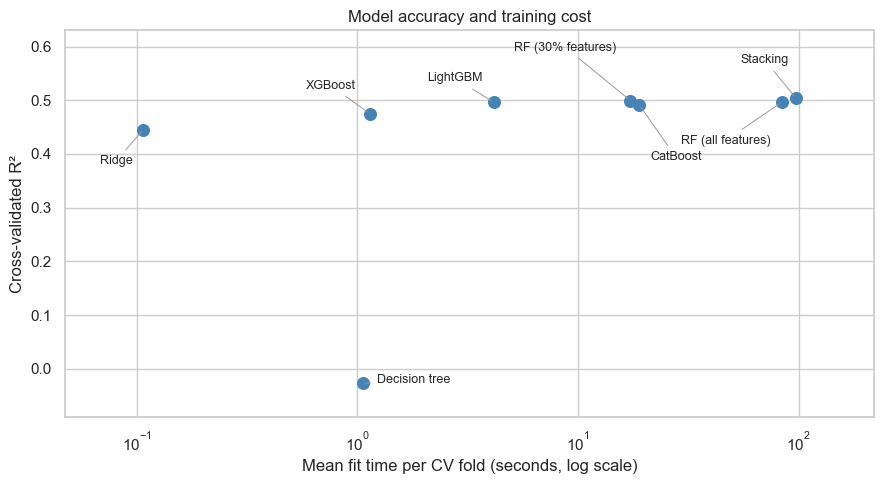

In [33]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = results.drop(index=["baseline", "baseline_logged"], errors="ignore")
labels = {
    "ridge": ("Ridge", (-8, -25), "right"),
    "decision_tree": ("Decision tree", (10, 0), "left"),
    "rf_maxfeat_1.0": ("RF (all features)", (-8, -30), "right"),
    "rf_maxfeat_0.3": ("RF (30% features)", (-10, 36), "right"),
    "lightgbm": ("LightGBM", (-8, 15), "right"),
    "xgboost": ("XGBoost", (-10, 18), "right"),
    "catboost": ("CatBoost", (8, -40), "left"),
    "stacking": ("Stacking", (-5, 25), "right"),
}

ax.scatter(plot_df["fit_time"], plot_df["r2"], s=70, color="steelblue")
for name, row in plot_df.iterrows():
    label, offset, align = labels[name]
    ax.annotate(
        label, (row["fit_time"], row["r2"]),
        textcoords="offset points", xytext=offset, fontsize=9, ha=align,
        arrowprops={"arrowstyle": "-", "color": "0.6", "lw": 0.7},
    )
ax.set_xscale("log")
ax.margins(x=0.12)
ax.set_ylim(-0.09, 0.63)
ax.set_xlabel("Mean fit time per CV fold (seconds, log scale)")
ax.set_ylabel("Cross-validated R²")
ax.set_title("Model accuracy and training cost")
fig.tight_layout()
save_fig(fig, "accuracy_vs_cost")
plt.show()

### Recheck the missing-target policy

Repeat section 2's Ridge/six-numeric-feature comparison using the full preprocessing pipeline and LightGBM. Both training policies are evaluated on the same observed-target validation rows.

In [34]:
recheck = cached(
    "policy_comparison_full",
    lambda: compare_target_policies(
        train_df,
        lambda: build_pipe(LGBMRegressor(random_state=RANDOM_STATE,
                                         verbose=-1, n_jobs=-1)),
    ),
)
print("scored on identical rows, the listings with a genuinely observed target")
print(recheck.groupby("policy")[["r2", "rmse", "mae"]]
      .agg(["mean", "std"]).round(4).to_string())

scored on identical rows, the listings with a genuinely observed target
            r2            rmse             mae        
          mean     std    mean     std    mean     std
policy                                                
drop    0.4986  0.0356  1.2215  0.0575  0.7063  0.0204
fill0   0.4500  0.0341  1.2793  0.0543  0.7199  0.0184


### Select a model for tuning

Use a cost-aware shortlist: models within one fold standard deviation of the highest mean R². This is a practical selection heuristic, not a significance test.

LightGBM was selected from that shortlist in the recorded development run. Keep that choice explicit so a change in machine load cannot silently change the model family used downstream.

In [35]:
ranked = results.drop(index=["baseline", "baseline_logged"], errors="ignore")
ranked = ranked.sort_values("r2", ascending=False)

BEST_MODEL_NAME = ranked.index[0]
top_r2 = ranked["r2"].iloc[0]
tolerance = ranked["r2_std"].iloc[0]
close_enough = ranked[ranked["r2"] >= top_r2 - tolerance]
# Fixed from the recorded development comparison, not the current machine load.
WORKING_MODEL_NAME = "lightgbm"

print(ranked[["r2", "r2_std", "rmse", "mae", "fit_time"]].round(4).to_string())
print(f"\nbest by R squared:  {BEST_MODEL_NAME} ({top_r2:.4f})")
print(f"within the one-fold-SD heuristic band ({tolerance:.4f}) of it: "
      f"{list(close_enough.index)}")
print(f"\ncarried into sections 9 to 12: {WORKING_MODEL_NAME}")
print(f"  gives up {top_r2 - ranked.loc[WORKING_MODEL_NAME, 'r2']:.4f} R squared")
print(f"  saves    {ranked.loc[BEST_MODEL_NAME, 'fit_time'] - ranked.loc[WORKING_MODEL_NAME, 'fit_time']:.1f}s per fit "
      f"({ranked.loc[BEST_MODEL_NAME, 'fit_time'] / ranked.loc[WORKING_MODEL_NAME, 'fit_time']:.1f}x faster)")

                    r2  r2_std    rmse     mae  fit_time
model                                                   
stacking        0.5045  0.0190  1.2143  0.6992   96.8648
rf_maxfeat_0.3  0.4994  0.0159  1.2205  0.6994   17.2585
rf_maxfeat_1.0  0.4969  0.0176  1.2235  0.7044   84.0015
lightgbm        0.4965  0.0221  1.2241  0.7092    4.1440
catboost        0.4918  0.0193  1.2298  0.7138   18.9035
xgboost         0.4753  0.0233  1.2495  0.7271    1.1361
ridge           0.4454  0.0207  1.2847  0.7547    0.1073
decision_tree  -0.0270  0.1041  1.7448  0.9968    1.0594

best by R squared:  stacking (0.5045)
within the one-fold-SD heuristic band (0.0190) of it: ['stacking', 'rf_maxfeat_0.3', 'rf_maxfeat_1.0', 'lightgbm', 'catboost']

carried into sections 9 to 12: lightgbm
  gives up 0.0080 R squared
  saves    92.7s per fit (23.4x faster)


In [36]:
# Keep downstream experiments tied to the chosen model family.
assert WORKING_MODEL_NAME == "lightgbm"


def best_model_factory():
    return LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)


print(f"working estimator: {type(best_model_factory()).__name__}")

working estimator: LGBMRegressor


The missing-target recheck favors dropping on observed validation rows: R² 0.4986 versus 0.4500, with lower RMSE and MAE as well. This supports the conditional prediction task; it does not quantify performance on excluded listings.

Continue with LightGBM, retaining all feature groups.

Ensemble models outperform Ridge in cross-validation, suggesting that nonlinear relationships  or feature interactions may improve prediction. However, the R² difference cannot be interpreted as the amount of signal that is nonlinear.

---

## 9. Feature selection

Compare two selectors with two estimators, Ridge and LightGBM:

- `SelectFromModel`: retain features at or above median importance.
- `RFECV`: recursively remove low-ranked features and select the subset size
  with the highest three-fold validation R².

Ridge supplies coefficient magnitudes and is inexpensive to refit. LightGBM supplies split counts and can use nonlinear relationships. Running the 2×2 comparison separates the choice of selector from the choice of estimator.

The first comparison is exploratory: preprocessing is fitted once on all training rows, and RFECV scores `log1p(y)`. Its inner scores are not unbiased performance estimates. A separate experiment below refits preprocessing and selection within each outer fold and scores the original target.

In [37]:
prep_fitted = build_preprocessor().fit(X_train, y_train)
Xt = prep_fitted.transform(X_train)
names = prep_fitted.named_steps["columns"].get_feature_names_out()
y_log = np.log1p(y_train)

print(f"{Xt.shape[1]:,} features going into selection")

560 features going into selection


In [38]:
from sklearn.feature_selection import RFECV, SelectFromModel


def make_estimator(kind):
    if kind == "ridge":
        return Ridge()
    return LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)


def run_selection(algorithm, estimator_kind):
    """Return the boolean keep-mask for one algorithm and estimator pairing."""
    est = make_estimator(estimator_kind)
    if algorithm == "importance":
        return SelectFromModel(est, threshold="median").fit(Xt, y_log).get_support()
    return RFECV(estimator=est, step=0.1, min_features_to_select=10,
                 cv=3, scoring="r2", n_jobs=-1).fit(Xt, y_log).support_


masks = {}
for algorithm in ["importance", "elimination"]:
    for estimator_kind in ["ridge", "lightgbm"]:
        key = f"{algorithm}+{estimator_kind}"
        masks[key] = cached(f"select_{algorithm}_{estimator_kind}",
                            lambda a=algorithm, e=estimator_kind: run_selection(a, e))
        print(f"{key:<24} kept {masks[key].sum():>3} of {len(names)}")

importance+ridge         kept 280 of 560
importance+lightgbm      kept 280 of 560
elimination+ridge        kept 560 of 560
elimination+lightgbm     kept 280 of 560


In [39]:
grid = pd.DataFrame(
    [[int(masks[f"{a}+{e}"].sum()) for e in ["ridge", "lightgbm"]]
     for a in ["importance", "elimination"]],
    index=["importance based", "recursive elimination"],
    columns=["Ridge", "LightGBM"],
)
print(f"features kept, out of {Xt.shape[1]}")
print(grid.to_string())

features kept, out of 560
                       Ridge  LightGBM
importance based         280       280
recursive elimination    560       280


In [40]:
lgbm_full = LGBMRegressor(random_state=RANDOM_STATE, verbose=-1,
                          n_jobs=-1).fit(Xt, y_log)
imp = pd.Series(lgbm_full.feature_importances_, index=names).sort_values(
    ascending=False)
share = imp.cumsum() / imp.sum()

print("distribution of split usage")
for k in [10, 20, 50, 100, 200]:
    print(f"  top {k:>3} features carry {share.iloc[k - 1]:.1%} of all splits")
print(f"\nfeatures the model never split on: {(imp == 0).sum():,} "
      f"({(imp == 0).mean():.1%})")
print("\nten most used features")
print(imp.head(10).to_string())

distribution of split usage
  top  10 features carry 47.2% of all splits
  top  20 features carry 56.7% of all splits
  top  50 features carry 70.3% of all splits
  top 100 features carry 83.0% of all splits
  top 200 features carry 96.2% of all splits

features the model never split on: 280 (50.0%)

ten most used features
num__availability_365                  233
log_num__total_min_cost                199
num__latitude                          169
num__longitude                         162
log_num__price                         148
num__name_caps_ratio                   146
num__calculated_host_listings_count    119
num__name_len                          106
log_num__minimum_nights                 76
text__parking                           58


In [41]:
keys = list(masks)
agree = pd.DataFrame(index=keys, columns=keys, dtype=float)
for a in keys:
    for b in keys:
        both = int((masks[a] & masks[b]).sum())
        union = int((masks[a] | masks[b]).sum())
        agree.loc[a, b] = both / union if union else 1.0

print("Jaccard similarity: intersection / union")
print((agree * 100).round(1).to_string())

Jaccard similarity: intersection / union
                      importance+ridge  importance+lightgbm  elimination+ridge  elimination+lightgbm
importance+ridge                 100.0                 44.3               50.0                  44.3
importance+lightgbm               44.3                100.0               50.0                 100.0
elimination+ridge                 50.0                 50.0              100.0                  50.0
elimination+lightgbm              44.3                100.0               50.0                 100.0


### Selection results

Median-threshold selection keeps 280 columns with either estimator. RFECV keeps 560 with Ridge and 280 with LightGBM.

Keeping all features is a valid RFECV result: among the candidate sizes along its elimination path, the full set scored best for Ridge. This neither proves that every feature is necessary nor makes Ridge an invalid estimator for RFECV.

The two LightGBM selectors produce identical full-training masks. The two median-threshold masks share 172 features, a Jaccard similarity of 44.3%. These are results for this fit, not guaranteed agreement on other folds. Median thresholds can retain more than half the columns when importance values tie.

LightGBM never splits on 280 columns in this fit. Split counts measure usage, not the improvement caused by a feature; continuous inputs offer more candidate thresholds. A tree can use `minimum_nights` to recover a boundary represented explicitly by `is_28_plus`. Coefficient magnitudes and split counts consequently need not rank the same features.

### Evaluate selection inside cross-validation

Compare no selection, median-threshold selection, and caps of 100 or 50 features using untuned LightGBM. Preprocessing and selection are refitted on each outer training fold, and scores use the original review-rate scale.

The reported feature counts come from fitting on all training rows; counts and selected identities can differ within folds. Full-training agreement between selectors does not imply that their fold-specific selections would be identical.

In [42]:
from sklearn.feature_selection import SelectFromModel as _SFM


def build_pipe_selected(threshold=None, max_features=None):
    """Boosting model with feature selection refitted inside every fold."""
    inner = Pipeline([
        ("prep", build_preprocessor()),
        ("select", _SFM(
            LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
            threshold=threshold, max_features=max_features)),
        ("model", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)),
    ])
    return TransformedTargetRegressor(regressor=inner, func=np.log1p,
                                      inverse_func=expm1_floor)


selection_settings = [
    ("all 560 features", None, None),
    ("keep half", "median", None),
    ("keep top 100", -np.inf, 100),
    ("keep top 50", -np.inf, 50),
]

sel_rows = []
for label, thr, maxf in selection_settings:
    if thr is None and maxf is None:
        row = results.loc[["lightgbm"]].copy()
        row.index = [label]
        kept = Xt.shape[1]
    else:
        row = score_model(build_pipe_selected(thr, maxf),
                          f"sel_{label.replace(' ', '_')}")
        row.index = [label]
        kept = int(build_pipe_selected(thr, maxf).fit(X_train, y_train)
                   .regressor_.named_steps["select"].get_support().sum())
    row["features"] = kept
    sel_rows.append(row)

selection_table = pd.concat(sel_rows)[["features", "r2", "r2_std", "rmse", "mae",
                                        "fit_time"]].round(4)
selection_table

,features,r2,r2_std,rmse,mae,fit_time
all 560 features,560,0.4965,0.0221,1.2241,0.7092,4.1440
keep half,280,0.4964,0.0222,1.2242,0.7091,5.7941
keep top 100,100,0.4934,0.0208,1.2279,0.7122,4.6221
keep top 50,50,0.4947,0.0178,1.2263,0.7088,4.6316


In [43]:
full = selection_table.loc["all 560 features"]
print("change against using every feature")
for label in selection_table.index[1:]:
    row = selection_table.loc[label]
    print(f"  {label:<16} {int(row.features):>3} features  "
          f"R2 {row.r2 - full.r2:+.4f}  RMSE {row.rmse - full.rmse:+.4f}  "
          f"MAE {row.mae - full.mae:+.4f}")
print(f"\nfold to fold variation of the full model: {full.r2_std:.4f}")

change against using every feature
  keep half        280 features  R2 -0.0001  RMSE +0.0001  MAE -0.0001
  keep top 100     100 features  R2 -0.0031  RMSE +0.0038  MAE +0.0030
  keep top 50       50 features  R2 -0.0018  RMSE +0.0022  MAE -0.0004

fold to fold variation of the full model: 0.0221


The 50-feature setting gives validation R² 0.4947 versus 0.4965 without selection; MAE is 0.7088 versus 0.7092. These point estimates show a small accuracy difference, not proof of equivalence. Non-monotonic scores across subset sizes do not establish that the differences are noise.

Selection adds another model fit inside each fold and did not reduce measured training time. Retain the unselected pipeline for the final experiment. A compact alternative remains worth testing, but these untuned-model results do not establish equivalence to the tuned model or lower serving latency: the current pipeline still computes all transformed features before selecting.

---

## 10. Hyperparameter search

Run `RandomizedSearchCV` for 40 configurations with five folds (200 candidate
fits plus a final refit), selecting by original-scale R².

The search varies tree count, learning rate, number of leaves, minimum leaf size,
column sampling, and L2 regularization. The historical sampling grid also contains
`subsample`, but LightGBM's `subsample_freq=0` disables row sampling: there are
six effective hyperparameters, not seven. That inactive field is retained only to
reproduce the original random draws; it is not evidence of a row-sampling experiment.

In [44]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "regressor__model__n_estimators": randint(200, 1200),
    "regressor__model__learning_rate": loguniform(0.01, 0.3),
    "regressor__model__num_leaves": randint(15, 128),
    "regressor__model__min_child_samples": randint(5, 80),
    # Inactive with subsample_freq=0; retained to reproduce the original draws.
    "regressor__model__subsample": [0.7, 0.8, 0.9, 1.0],
    "regressor__model__colsample_bytree": [0.3, 0.5, 0.7, 1.0],
    "regressor__model__reg_lambda": loguniform(1e-3, 10),
}
N_ITER = 40

print(f"tuning {WORKING_MODEL_NAME}: six active hyperparameters")
print(f"{N_ITER} configurations × {CV.n_splits} folds, plus the final refit")
print("subsample is retained for sampling reproducibility; row sampling is disabled")

tuning lightgbm: six active hyperparameters
40 configurations × 5 folds, plus the final refit
subsample is retained for sampling reproducibility; row sampling is disabled


In [45]:
def run_search():
    search = RandomizedSearchCV(
        build_pipe(best_model_factory()),
        param_distributions=param_dist,
        n_iter=N_ITER, cv=CV, scoring="r2",
        random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True,
    )
    search.fit(X_train, y_train)
    return search


search = cached("random_search", run_search)

print(f"best cross-validated R squared: {search.best_score_:.4f}")
print(f"untuned, from section 8:        "
      f"{results.loc[WORKING_MODEL_NAME, 'r2']:.4f}")
print(f"gain from tuning:               "
      f"{search.best_score_ - results.loc[WORKING_MODEL_NAME, 'r2']:+.4f}")
print("\nsettings chosen")
for key, value in sorted(search.best_params_.items()):
    print(f"  {key.split('__')[-1]:<22} {value}")

best cross-validated R squared: 0.5067
untuned, from section 8:        0.4965
gain from tuning:               +0.0102

settings chosen
  colsample_bytree       0.5
  learning_rate          0.02028406763400795
  min_child_samples      8
  n_estimators           1021
  num_leaves             107
  reg_lambda             7.556810141274429
  subsample              0.8


In [46]:
cvres = pd.DataFrame(search.cv_results_)
top = cvres.nlargest(5, "mean_test_score")[["mean_test_score", "std_test_score"]]
top.index = [f"rank {i}" for i in range(1, len(top) + 1)]
print(top.round(4).to_string())
print("\nFold standard deviations describe variation, not statistical significance.")

        mean_test_score  std_test_score
rank 1           0.5067          0.0211
rank 2           0.5062          0.0208
rank 3           0.5028          0.0221
rank 4           0.5015          0.0200
rank 5           0.5009          0.0214

Fold standard deviations describe variation, not statistical significance.


In [47]:
tuned_model = search.best_estimator_
results = pd.concat([results, score_model(tuned_model, "tuned")])
results.loc[[WORKING_MODEL_NAME, "tuned", "stacking"]].round(4)

,fit_time,score_time,train_r2,r2,r2_std,rmse,mae
model,,,,,,,
lightgbm,4.1440,0.0368,0.6433,0.4965,0.0221,1.2241,0.7092
tuned,115.4675,0.3543,0.8773,0.5067,0.0211,1.2116,0.7012
stacking,96.8648,0.1053,0.7959,0.5045,0.0190,1.2143,0.6992


### Search results

The selected configuration raises mean validation R² from 0.4965 to 0.5067. The top five configurations range from 0.5009 to 0.5067. Their fold standard deviations describe split variation, not a test of statistical significance.

The best score is a model-selection result from the same folds used for tuning. Reevaluating that configuration on those folds does not provide independent validation. Use the held-out test set for the final estimate ([nested versus non-nested CV](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html)).

Recorded mean fit time rises from 4.1 to 115.5 seconds, while stacking takes 96.9 seconds. The tuned model is retained as the accuracy-focused experiment; untuned LightGBM remains the lower-cost alternative.

---

## 11. Model interpretation

Use two complementary diagnostics:

- **Permutation importance:** shuffle an original input column and measure the fitted model's R² decrease.
- **SHAP:** decompose a prediction into a base value and feature contributions.

Both analyses below use training samples and describe the fitted model, not held-out importance or causal effects. Permutation scores use original-scale R²; SHAP values explain the underlying model's log-scale output.

In [48]:
from sklearn.inspection import permutation_importance


def run_perm():
    sample = X_train.sample(3000, random_state=RANDOM_STATE)
    return permutation_importance(
        tuned_model, sample, y_train.loc[sample.index],
        n_repeats=5, random_state=RANDOM_STATE, scoring="r2", n_jobs=-1,
    )


perm = cached("permutation_importance", run_perm)
perm_table = pd.DataFrame({
    "drop in R squared": perm.importances_mean,
    "variation": perm.importances_std,
}, index=X_train.columns).sort_values("drop in R squared", ascending=False)
perm_table.round(4)

,drop in R squared,variation
minimum_nights,0.6873,0.0269
name,0.3557,0.0049
price,0.1977,0.0085
availability_365,0.1160,0.0072
latitude,0.0888,0.0038
calculated_host_listings_count,0.0622,0.0046
longitude,0.0584,0.0020
license,0.0511,0.0040
neighbourhood,0.0207,0.0006
room_type,0.0056,0.0003


Permutation acts on the ten original inputs and then reruns feature engineering.
For example, shuffling `name` changes both TF-IDF and title statistics.
This is a perturbation of the fitted pipeline, not retraining without a feature.
Correlations and unrealistic shuffled combinations can affect the result.

In [49]:
import shap

prep = tuned_model.regressor_.named_steps["prep"]
booster = tuned_model.regressor_.named_steps["model"]
names = prep.named_steps["columns"].get_feature_names_out()

def readable(col: str) -> str:
    """Strip the transformer prefix so plots carry names a reader recognises."""
    stem = col.split("__", 1)[1] if "__" in col else col
    return f"title word: {stem}" if col.startswith("text__") else stem


shap_sample = X_train.sample(2000, random_state=RANDOM_STATE)
Xs = prep.transform(shap_sample)
Xs_dense = Xs.toarray() if hasattr(Xs, "toarray") else np.asarray(Xs)

Xs_named = pd.DataFrame(Xs_dense, columns=[readable(n) for n in names])


def run_shap():
    explainer = shap.TreeExplainer(booster)
    return explainer(Xs_named), explainer.expected_value


shap_out, base_value = cached("shap_values", run_shap)
base_value = float(np.ravel(base_value)[0])

print(f"base value in log space:               {base_value:.4f}")
print(f"converted back to reviews per month:   {np.expm1(base_value):.4f}")
print(f"actual mean review rate in training:   {y_train.mean():.4f}")
print(f"actual median review rate in training: {y_train.median():.4f}")

base value in log space:               0.6938
converted back to reviews per month:   1.0012
actual mean review rate in training:   1.4162
actual median review rate in training: 0.7300


In [50]:
abs_shap = np.abs(shap_out.values).mean(axis=0)
shap_series = pd.Series(abs_shap, index=names)


def group_of(col: str) -> str:
    if col.startswith("text__"):
        return "name (title text)"
    if col.startswith("cat__neighbourhood"):
        return "neighbourhood"
    if col.startswith("cat__room_type"):
        return "room_type"
    if col.startswith("cat__license_status"):
        return "license_status"
    return col.split("__", 1)[-1]


grouped = shap_series.groupby(shap_series.index.map(group_of)).sum()
grouped = (grouped / grouped.sum() * 100).sort_values(ascending=False)
grouped.round(2).to_frame("share of summed mean absolute SHAP, percent")

,"share of summed mean absolute SHAP, percent"
name (title text),22.33
minimum_nights,21.48
license_status,10.76
is_28_plus,8.75
total_min_cost,8.39
availability_365,5.05
latitude,4.22
neighbourhood,3.15
name_len,2.60
longitude,2.55


### Interpretation

Minimum nights and title text rank highly in both diagnostics. Their scales and grouping differ, so the numerical values are not directly comparable.

Shuffling `price` also changes `total_min_cost` and `price_missing`, whereas the SHAP table reports these separately. License status has substantial SHAP contributions but a smaller permutation effect; overlap with minimum-stay information is a possible explanation, not a demonstrated mechanism.

For each transformed feature, we average the absolute SHAP values across the sampled training listings and then sum them within the original feature groups. The percentages show where the fitted model’s attribution magnitude is concentrated. They are not shares of R² or causal effects. Because this is a post-hoc sum rather than a grouped Shapley calculation, groups represented by many columns, such as title text, may accumulate larger values and should be interpreted carefully.

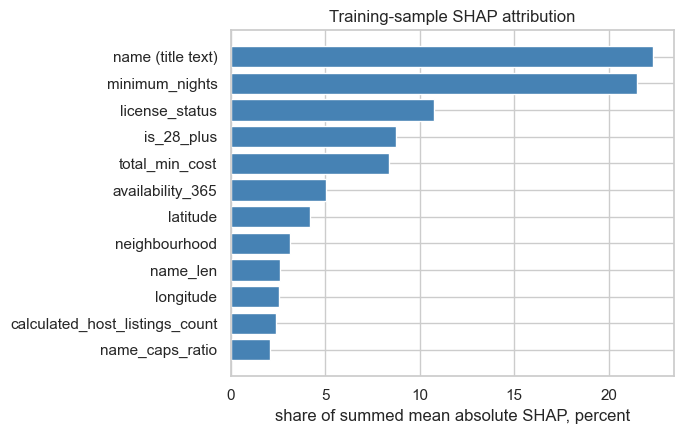

In [51]:
fig, ax = plt.subplots(figsize=(7, 4.5))
top12 = grouped.head(12).sort_values()
ax.barh(top12.index, top12.values, color="steelblue")
ax.set_xlabel("share of summed mean absolute SHAP, percent")
ax.set_title("Training-sample SHAP attribution")
fig.tight_layout()
save_fig(fig, "feature_importance")
plt.show()

### Performance within minimum-stay segments

Evaluate out-of-fold predictions both pooled and within each segment. Also compute a simple baseline that predicts each segment's mean using only that fold's training rows.

The tuned parameters were selected using these development folds, so these OOF diagnostics are not nested estimates of the complete tuning procedure.

In [52]:
from sklearn.model_selection import cross_val_predict

oof = cached(
    "oof_predictions",
    lambda: cross_val_predict(tuned_model, X_train, y_train, cv=CV, n_jobs=-1),
)

market = np.where(X_train["minimum_nights"] >= 28,
                  "B: 28 nights and up", "A: under 28 nights")

# Each baseline prediction uses segment means learned on that fold's training rows.
segment_baseline = np.empty(len(y_train), dtype=float)
for tr_idx, va_idx in CV.split(X_train):
    segment_means = y_train.iloc[tr_idx].groupby(market[tr_idx]).mean()
    segment_baseline[va_idx] = (
        pd.Series(market[va_idx]).map(segment_means).to_numpy()
    )

rows = []
for label, predictions in [
    ("pooled: tuned model", oof),
    ("pooled: segment-mean baseline", segment_baseline),
]:
    rows.append({
        "segment": label,
        "listings": len(y_train),
        "r2": r2_score(y_train, predictions),
        "rmse": root_mean_squared_error(y_train, predictions),
        "mae": mean_absolute_error(y_train, predictions),
        "median actual": y_train.median(),
    })
for g in np.unique(market):
    m = market == g
    rows.append({
        "segment": g,
        "listings": int(m.sum()),
        "r2": r2_score(y_train[m], oof[m]),
        "rmse": root_mean_squared_error(y_train[m], oof[m]),
        "mae": mean_absolute_error(y_train[m], oof[m]),
        "median actual": y_train[m].median(),
    })

by_group_scores = pd.DataFrame(rows).set_index("segment").round(4)
by_group_scores

,listings,r2,rmse,mae,median actual
segment,,,,,
pooled: tuned model,13956,0.5064,1.2124,0.7012,0.73
pooled: segment-mean baseline,13956,0.3501,1.3912,0.8847,0.73
A: under 28 nights,6367,0.2396,1.6640,1.1436,2.12
B: 28 nights and up,7589,0.2453,0.6165,0.3300,0.24


The tuned model's pooled development OOF R² is 0.5064, compared with 0.3501 for the fold-trained segment-mean baseline. This provides evidence of predictive information beyond minimum-stay grouping.

Within-segment R² is 0.2396 for under-28 listings and 0.2453 for 28-plus listings. These scores use different target-variance denominators and cannot be subtracted from pooled R² to say what fraction of performance comes from segment membership.

Absolute errors also differ: OOF MAE is 1.1436 in the under-28 segment and 0.3300 in the 28-plus segment. Report these alongside the pooled value of 0.7012. These are development diagnostics, not the held-out test results in section 12.

Summary: \
The minimum-stay split captures substantial predictive structure, but it does not explain the model’s full performance. The tuned model outperforms a fold-trained segment-mean baseline and retains similar predictive ability within both segments. Absolute errors are larger for under-28 listings because their review rates are higher and more variable.

In [53]:
pred_sample = tuned_model.predict(shap_sample)
hi, lo = int(np.argmax(pred_sample)), int(np.argmin(pred_sample))

for label, i in [("highest predicted", hi), ("lowest predicted", lo)]:
    row = shap_sample.iloc[i]
    print(f"--- {label} ---")
    print(f"  predicted {pred_sample[i]:.3f}   actual "
          f"{y_train.loc[row.name]:.3f}   reviews per month")
    for col in ["name", "neighbourhood", "room_type", "price",
                "minimum_nights", "availability_365", "license"]:
        print(f"  {col:<22} {row[col]}")
    print()

--- highest predicted ---
  predicted 8.222   actual 20.400   reviews per month
  name                   Chic Condo Sleeps 4, Parking, 10 mins to BMO Field
  neighbourhood          Niagara
  room_type              Entire home/apt
  price                  320.0
  minimum_nights         1
  availability_365       53
  license                STR-2604-JDJBPZ

--- lowest predicted ---
  predicted 0.007   actual 0.020   reviews per month
  name                   Lovely Victorian Family Home
  neighbourhood          Roncesvalles
  room_type              Entire home/apt
  price                  nan
  minimum_nights         28
  availability_365       0
  license                nan



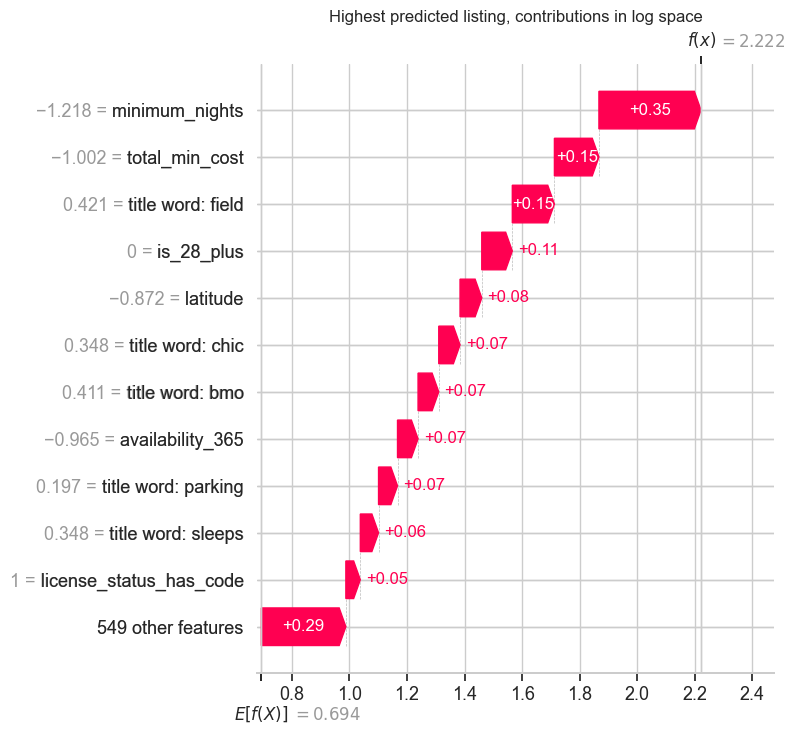

In [54]:
shap.plots.waterfall(shap_out[hi], max_display=12, show=False)
plt.title("Highest predicted listing, contributions in log space")
plt.tight_layout()
plt.show()

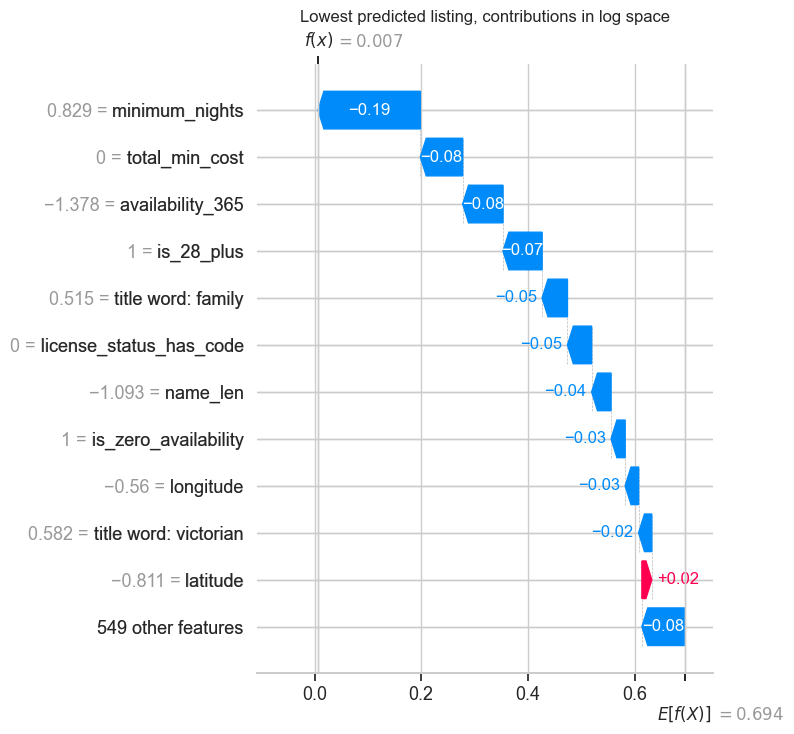

In [55]:
shap.plots.waterfall(shap_out[lo], max_display=12, show=False)
plt.title("Lowest predicted listing, contributions in log space")
plt.tight_layout()
plt.show()

### Individual explanations

Among the sampled training listings, the highest prediction is 8.222 reviews per
month against an observed 20.400; the lowest is 0.007 against 0.020. These
illustrations show how the fitted model combines features, not independent
validation examples or calibrated confidence estimates.

The waterfall bars add to the model's log-scale prediction. Apply `expm1`
to the complete sum to recover a review rate. The base value is about 0.6938
in log space, equivalent to 1.0012 after conversion.

---

## 12. Held-out test evaluation

Evaluate the selected configuration on the reserved observed-target test partition.
Model family and hyperparameters are not changed in response to test metrics.
Compare against training-mean and training-median baselines.

In [56]:
final_model = search.best_estimator_
final_model.fit(X_train, y_train)
test_pred = final_model.predict(X_test)
assert np.isfinite(test_pred).all()


def regression_metrics(actual, predicted):
    return {
        "r2": r2_score(actual, predicted),
        "rmse": root_mean_squared_error(actual, predicted),
        "mae": mean_absolute_error(actual, predicted),
    }


test_scores = regression_metrics(y_test, test_pred)
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_scores = regression_metrics(y_test, baseline_pred)
median_scores = regression_metrics(
    y_test, np.full(len(y_test), y_train.median())
)

final_table = pd.DataFrame({
    "LightGBM": test_scores,
    "training-mean baseline": baseline_scores,
    "training-median baseline": median_scores,
}).round(4)
print(f"held-out listings with observed targets: {len(y_test):,}")
final_table

held-out listings with observed targets: 3,445


,LightGBM,training-mean baseline,training-median baseline
r2,0.5312,-0.0000,-0.1632
rmse,1.1768,1.7186,1.8535
mae,0.6951,1.2963,1.1880


In [57]:
print(f"selected mean development CV R²: {search.best_score_:.4f}")
print(f"held-out test R²:                {test_scores['r2']:.4f}")
print(f"test minus development CV:       {test_scores['r2'] - search.best_score_:+.4f}")
shared_host = test_use["host_id"].isin(train_use["host_id"].dropna())
print(f"test listings with a training-set host: "
      f"{shared_host.sum():,} / {len(shared_host):,} ({shared_host.mean():.1%})")

selected mean development CV R²: 0.5067
held-out test R²:                0.5312
test minus development CV:       +0.0245
test listings with a training-set host: 1,349 / 3,445 (39.2%)


The tuned LightGBM achieved a held-out test R² of 0.5312, consistent with its mean development CV R² of 0.5067. The test result evaluates unseen listing rows, but not necessarily unseen hosts, because 39.2% of test listings share a host with the training set. Future-period and unseen-host performance require temporal and group-based evaluation.

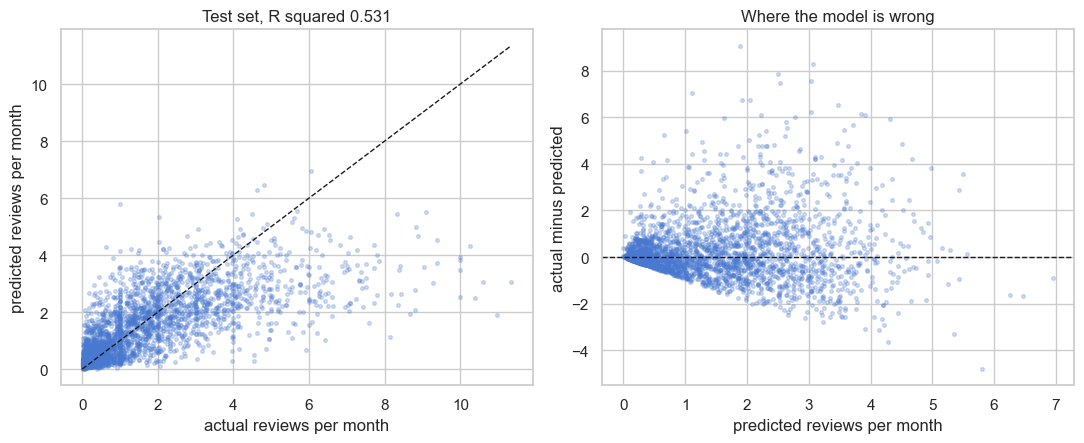

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

axes[0].scatter(y_test, test_pred, s=7, alpha=0.25)
lim = float(max(y_test.max(), test_pred.max()))
axes[0].plot([0, lim], [0, lim], "k--", linewidth=1)
axes[0].set_xlabel("actual reviews per month")
axes[0].set_ylabel("predicted reviews per month")
axes[0].set_title(f"Test set, R squared {test_scores['r2']:.3f}")

residual = y_test.to_numpy() - test_pred
axes[1].scatter(test_pred, residual, s=7, alpha=0.25)
axes[1].axhline(0, color="k", linestyle="--", linewidth=1)
axes[1].set_xlabel("predicted reviews per month")
axes[1].set_ylabel("actual minus predicted")
axes[1].set_title("Where the model is wrong")

fig.tight_layout()
save_fig(fig, "test_predictions")
plt.show()

---

## 13. Results summary

The tuned LightGBM model achieves test R² 0.5312, RMSE 1.1768, and MAE 0.6951
on 3,445 listings with observed review rates. RMSE is 31.5% below the training-mean
baseline (1.7186). MAE is 46.4% below that baseline and 41.5% below the
training-median baseline (1.1880).

The model comparison below contains development CV scores; the test table in
section 12 is the final held-out result. The tuned row is post-selection CV.

In [59]:
summary_view = results.drop(index=["baseline_logged"], errors="ignore")
summary_view = summary_view.sort_values("r2", ascending=False)
summary_view[["r2", "r2_std", "rmse", "mae", "fit_time"]].round(4)

,r2,r2_std,rmse,mae,fit_time
model,,,,,
tuned,0.5067,0.0211,1.2116,0.7012,115.4675
stacking,0.5045,0.0190,1.2143,0.6992,96.8648
rf_maxfeat_0.3,0.4994,0.0159,1.2205,0.6994,17.2585
rf_maxfeat_1.0,0.4969,0.0176,1.2235,0.7044,84.0015
lightgbm,0.4965,0.0221,1.2241,0.7092,4.1440
catboost,0.4918,0.0193,1.2298,0.7138,18.9035
xgboost,0.4753,0.0233,1.2495,0.7271,1.1361
ridge,0.4454,0.0207,1.2847,0.7547,0.1073
baseline,-0.0005,0.0006,1.7256,1.2837,0.0884


---

## 14. Limitations and next steps

- **What the target measures.** `reviews_per_month` measures how often reviews are
  recorded. It is influenced by booking turnover and whether guests leave reviews,
  so it should not be interpreted as occupancy, revenue, or overall popularity.
- **Who the results apply to.** Listings with missing review rates were excluded.
  The reported metrics therefore describe listings with recorded review rates, not
  all listings or listings waiting for their first review.
- **What the test split measures.** The test set contains new listing rows, but not
  always new hosts. Of the 3,445 test listings, 1,349 (39.2%) share a host with the
  training set. The result therefore does not establish performance for entirely
  new hosts. Because listing information can change over time, it also does not
  validate future-period or pre-publication predictions.
- **Uncertainty from model selection.** The same development folds were used to
  compare models and tune hyperparameters. The selected mean CV scores may therefore
  be optimistic and should not be treated as independent final estimates. The
  separate test set provides the final row-level evaluation.
- **Scope of the exploratory analyses.** Some initial feature-selection comparisons
  reused preprocessing fitted on all development rows, while permutation importance
  and SHAP used training samples. These analyses help explain the fitted model, but
  they do not provide independent performance estimates or causal evidence.
- **Stability of the errors.** Residual plots indicate underprediction at high review
  rates. Because the evaluation uses one random train-test split, it does not show
  whether the same error pattern will remain stable across time, hosts, or
  neighborhoods.